In [ ]:
%pip install -q tensorflow matplotlib scikit-learn seaborn


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import os
import glob
import random
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report , confusion_matrix
from sklearn.utils.class_weight import compute_class_weight
import seaborn as sns

print("TensorFlow:",tf.__version__)
print("GPU available:,",tf.config.list_physical_devices('GPU'))


SEED = 42 
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow: 2.21.0
GPU available:, []


In [4]:
DATA_ROOT = "PlantVillage-Dataset"
if not os.path.exists(DATA_ROOT):
    !git clone --depth 1 https://github.com/spMohanty/PlantVillage-Dataset.git

DATA_DIR = os.path.join(DATA_ROOT , "raw","color")
print("Data dir:", DATA_DIR)
print("Number of classes:",len(os.listdir(DATA_DIR)))


Data dir: PlantVillage-Dataset\raw\color
Number of classes: 38


Cloning into 'PlantVillage-Dataset'...
Updating files:   0% (1218/182404)
Updating files:   1% (1825/182404)
Updating files:   1% (2820/182404)
Updating files:   2% (3649/182404)
Updating files:   2% (4094/182404)
Updating files:   3% (5473/182404)
Updating files:   3% (5802/182404)
Updating files:   3% (6445/182404)
Updating files:   4% (7297/182404)
Updating files:   4% (7588/182404)
Updating files:   4% (8668/182404)
Updating files:   5% (9121/182404)
Updating files:   5% (10029/182404)
Updating files:   6% (10945/182404)
Updating files:   6% (11244/182404)
Updating files:   7% (12769/182404)
Updating files:   7% (12772/182404)
Updating files:   7% (13441/182404)
Updating files:   8% (14593/182404)
Updating files:   8% (14927/182404)
Updating files:   9% (16417/182404)
Updating files:   9% (16435/182404)
Updating files:   9% (17634/182404)
Updating files:  10% (18241/182404)
Updating files:  10% (19030/182404)
Updating files:  10% (19703/182404)
Updating files:  11% (20065/182404)
U

In [9]:
class_names = os.listdir(DATA_DIR)
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite',

In [10]:
class_names = sorted(os.listdir(DATA_DIR))
class_counts = {
    c : len(os.listdir(os.path.join(DATA_DIR , c)))
    for c in class_names
}
print(class_counts)

{'Apple___Apple_scab': 630, 'Apple___Black_rot': 621, 'Apple___Cedar_apple_rust': 275, 'Apple___healthy': 1645, 'Blueberry___healthy': 1502, 'Cherry_(including_sour)___Powdery_mildew': 1052, 'Cherry_(including_sour)___healthy': 854, 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': 513, 'Corn_(maize)___Common_rust_': 1192, 'Corn_(maize)___Northern_Leaf_Blight': 985, 'Corn_(maize)___healthy': 1162, 'Grape___Black_rot': 1180, 'Grape___Esca_(Black_Measles)': 1383, 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': 1076, 'Grape___healthy': 423, 'Orange___Haunglongbing_(Citrus_greening)': 5507, 'Peach___Bacterial_spot': 2297, 'Peach___healthy': 360, 'Pepper,_bell___Bacterial_spot': 997, 'Pepper,_bell___healthy': 1478, 'Potato___Early_blight': 1000, 'Potato___Late_blight': 1000, 'Potato___healthy': 152, 'Raspberry___healthy': 371, 'Soybean___healthy': 5090, 'Squash___Powdery_mildew': 1835, 'Strawberry___Leaf_scorch': 1109, 'Strawberry___healthy': 456, 'Tomato___Bacterial_spot': 2127, 'Tomato_

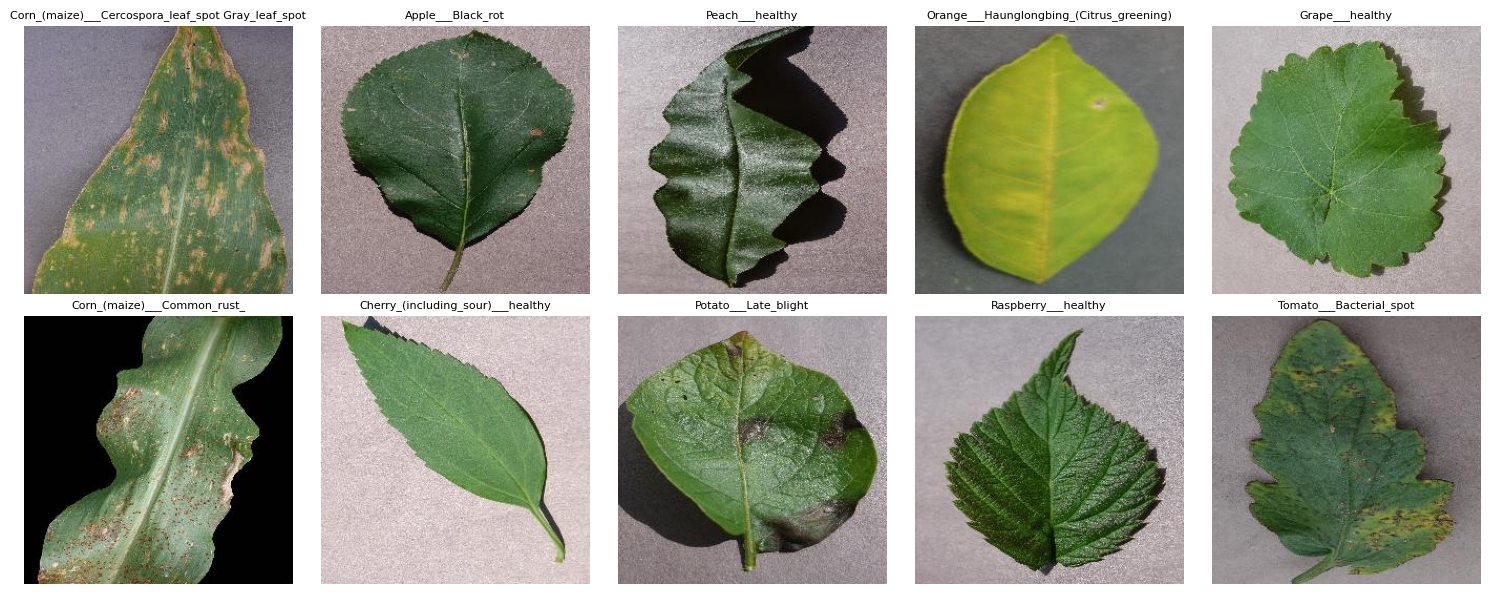

In [7]:
fig , axes = plt.subplots(2 , 5 , figsize=(15,6))
sample_classes = random.sample(class_names , 10)
for ax , cls in zip(axes.flatten(),sample_classes):
    img_path = random.choice(glob.glob(os.path.join(DATA_DIR , cls , '*')))
    img = keras.utils.load_img(img_path)
    ax.imshow(img)
    ax.set_title(cls , fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [8]:
IMG_SIZE = (224 , 224)
BATCH_SIZE = 32 

all_paths , all_labels = [] , []
for idx , clas in enumerate(class_names):
    files = glob.glob(os.path.join(DATA_DIR , cls , '*'))
    all_paths.extend(files)
    all_labels.extend([idx] * len(files))

all_paths = np.array(all_paths)
all_labels = np.array(all_labels)

train_paths , temp_paths , train_labels , temp_labels = train_test_split(
    all_paths , all_labels , test_size=0.3 , stratify=all_labels , random_state=SEED
)
val_paths , test_paths , val_labels , test_labels = train_test_split(
    temp_paths , temp_labels , test_size=0.5 , stratify=temp_labels , random_state=SEED
)
print(f"Train:{len(train_paths)} Val: {len(val_paths)} Test: {len(test_paths)}")


Train:56578 Val: 12124 Test: 12124
